# Appendices

Kept out of `quantile_learning.ipynb` because none of this is part of the
experiment: these are the three demonstrations that delimit the hypotheses,
and they are run once and quoted, not swept.

* **A.1** contractivity cannot simply be dropped: rescale the state weights of
  a fitted map and watch uniqueness fail.
* **A.2** a recursion with provably two solutions, so that the failure in A.1
  is not an artefact of the fit.
* **B** a chaotic drift with stochastic forcing: the contraction condition is
  sufficient and, on this family, short of necessary by about a factor of
  three; the operative boundary is a negative Lyapunov exponent.

In [30]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
import config as CFG
from backend import resolve, describe
torch.set_num_threads(getattr(CFG, "TORCH_THREADS", 2))
DEVICE, DTYPE = resolve(CFG.DEVICE, CFG.DTYPE)
print(describe(DEVICE, DTYPE))

from generators.synthetic_generators import build_target
from generators.quantile_generator import ClosedQuantileRecursion
from generators.simulate_paths import simulate, make_windows, initial_spread
from fit_generator import fit
from utils.hypotheses import lipschitz_empirical, theta_hat
from utils.marginal import w1_marginal
from utils.autocorrelation import acf
from utils.lyapunov import lyapunov, lyapunov_decomposition
from utils.plotting import C_TARGET, C_GEN, C_BASE, C_RULE, C_BOUND, ramp


# How many DISTINCT solutions did the 24 starts land on, and how tight is each?
# The spread is a single number and cannot tell "all 24 converged to one path"
# from "they split into two groups, each internally exact".  That distinction is
# the whole difference between a unique solution and several, so it is measured
# rather than eyeballed.
def basins(trj, tol=1e-6):
    end = np.sort(np.asarray(trj)[:, -1])
    groups = np.split(end, np.nonzero(np.diff(end) > tol)[0] + 1)
    return (len(groups), [len(g) for g in groups],
            max(float(g.max() - g.min()) for g in groups),
            [float(g.mean()) for g in groups])

M = 1.0

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
device cpu  dtype float32  (cuda available: False, mps available: True)


## Appendix A. The contraction condition is sufficient, not necessary

The generated law is pinned to within $2\theta/(1-S)$ by the comparison
argument alone, which uses nothing about $\hat q$ beyond $\theta$.  What
contractivity of $\hat q$ buys is not the bound but everything the *adapted*
conclusion needs, and it buys it through uniqueness of the solution of the
closed recursion:

* a measurable selection from a multivalued solution set may read the whole
  innovation path, so innovation-adaptedness fails, and with it bicausality;
* the solution correspondence is shift equivariant while a measurable
  selection of it need not be, so stationarity fails.

Smallness of $\theta$ does not help:
$\Pi_{\mathcal X}(q + \theta\sin(z_1/\lambda))$ is within $\theta$ of $q$ and
has contraction constant of order $\theta/\lambda$.

### A.1 Rescale the state weights, and watch uniqueness fail

In [ ]:
# Fit a small net on a contractive target, then scale G by a growing factor.
# Scaling G multiplies every lag sensitivity, so sum_i Lip_i grows while the
# map stays continuous and X-valued.  The question is when the closed
# recursion stops forgetting where it started.

target = build_target("hetero", 0.65, CFG.TARGET_SPECIFICS["hetero"], M=M)
path = simulate(target, 20000, burn=2000, seed=1)
Z, Xs = make_windows(path, 2)
net0, _ = fit(Z, Xs, 2, width=256, epochs=300, lip_mode="penalty",
              pen_region="hood", L_max=0.95, lam=1.0, tail_frac=0.2, M=M,
              device=DEVICE, dtype=DTYPE)

import copy
rows = []
for f in (1.0, 1.4, 1.8, 2.2, 2.6, 3.0, 4.0):
    net = copy.deepcopy(net0)
    net.rescale_G(f)
    rec = ClosedQuantileRecursion(net)
    lip = float(lipschitz_empirical(net, np.random.default_rng(0).uniform(-M, M, (2000, 2))).sum())
    trj, spread = initial_spread(rec, n_steps=120, n_starts=24, M=M)
    gen = simulate(rec, 20000, burn=2000, seed=404)
    lam_val, _ = lyapunov(net, gen)
    # keep the SERIES and the TRAJECTORIES, not only the two scalars: the
    # collapse is a picture, and a table of endpoints cannot show whether the
    # chains merge, split in two, or wander.
    nb_, sizes, within, centres = basins(trj)
    rows.append(dict(factor=f, lip=lip, lam=lam_val, spread=spread, trj=trj,
                     sp40=spread[40], sp119=spread[-1], sd=float(gen.std()),
                     n_basins=nb_, sizes=sizes, within=within, centres=centres))
    print(f"  G x{f:<4.1f}  sum_i Lip_i {lip:6.3f}   lambda {lam_val:+7.3f}   "
          f"spread t=119 {spread[-1]:.2e}   solutions {nb_} {sizes}   "
          f"worst within-solution spread {within:.1e}")
    if nb_ > 1:
        print(f"              -> terminal values {np.round(centres, 5).tolist()}"
              f"   <- lambda < 0 and yet NOT unique: see the note below")

  G x1.0   sum_i Lip_i  1.050   lambda  -0.428   spread t=119 2.22e-16   solutions 1 [24]   worst within-solution spread 2.2e-16
  G x1.4   sum_i Lip_i  1.632   lambda  -0.171   spread t=119 1.23e-08   solutions 1 [24]   worst within-solution spread 1.2e-08
  G x1.8   sum_i Lip_i  2.164   lambda  -0.209   spread t=119 1.71e-07   solutions 1 [24]   worst within-solution spread 1.7e-07
  G x2.2   sum_i Lip_i  2.680   lambda  -0.406   spread t=119 1.60e+00   solutions 2 [15, 9]   worst within-solution spread 0.0e+00
              -> terminal values [-0.80975, 0.791]   <- lambda < 0 and yet NOT unique: see the note below
  G x2.6   sum_i Lip_i  3.196   lambda  -0.568   spread t=119 1.73e+00   solutions 2 [15, 9]   worst within-solution spread 0.0e+00
              -> terminal values [-0.82457, 0.90386]   <- lambda < 0 and yet NOT unique: see the note below
  G x3.0   sum_i Lip_i  3.649   lambda  -0.625   spread t=119 1.80e+00   solutions 2 [14, 10]   worst within-solution spread 0.0e+00
  

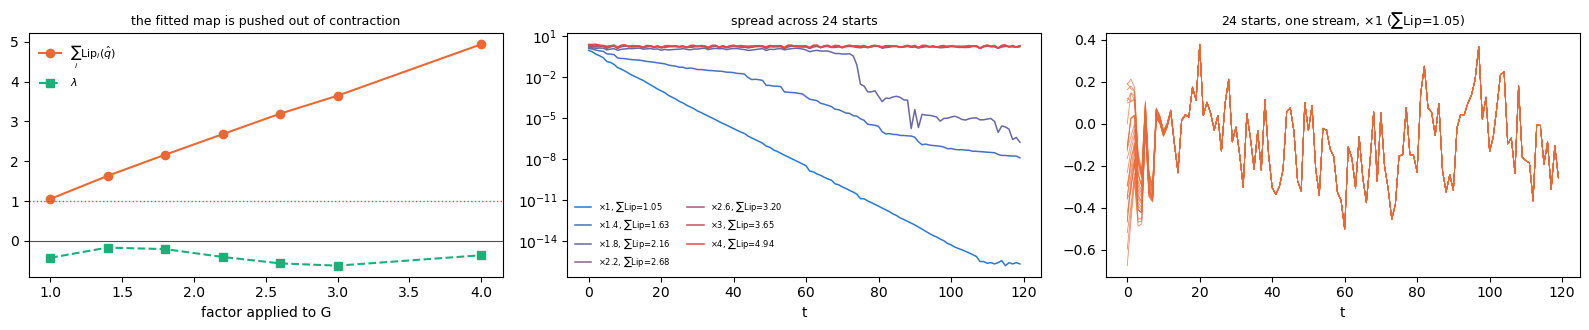

In [ ]:
cols = ramp(len(rows))
fig, ax = plt.subplots(1, 3, figsize=(16, 3.4))
f = [r["factor"] for r in rows]
ax[0].plot(f, [r["lip"] for r in rows], "o-", color=C_GEN, label=r"$\sum_i$Lip$_i(\hat q)$")
ax[0].plot(f, [r["lam"] for r in rows], "s--", color=C_BASE, label=r"$\lambda$")
ax[0].axhline(1, color=C_BOUND, ls=":", lw=1); ax[0].axhline(0, color=C_RULE, lw=.8)
ax[0].set_xlabel("factor applied to G"); ax[0].legend(fontsize=8, frameon=False)
ax[0].set_title("the fitted map is pushed out of contraction", fontsize=9)

# the spread as a function of t, one curve per factor.  This is the panel the
# scalar table replaced: it shows HOW the collapse stops, which is a change of
# rate first and then a floor, not a sudden switch.
for r, c in zip(rows, cols):
    ax[1].semilogy(np.maximum(r["spread"], 1e-18), lw=1.1, color=c,
                   label=fr"$\times${r['factor']:g}, $\sum$Lip={r['lip']:.2f}")
ax[1].set_xlabel("t"); ax[1].set_title("spread across 24 starts", fontsize=9)
ax[1].legend(fontsize=6, ncol=2, frameon=False)

# and the trajectories themselves, at the first factor that has left the
# contraction, so the failure is seen and not inferred
bad_candidates = [r for r in rows if r["lip"] >= 1.0]
bad = bad_candidates[-1] if bad_candidates else rows[-1]
for tr in bad["trj"]:
    ax[2].plot(tr, lw=.6, alpha=.75, color=C_GEN)
ax[2].set_xlabel("t")
ax[2].set_title(fr"24 starts, one stream, $\times${bad['factor']:g} "
                fr"($\sum$Lip={bad['lip']:.2f})", fontsize=9)
plt.tight_layout(); plt.show()

**What to read, and one thing that is easy to read wrongly.**

While $\sum_i\mathrm{Lip}_i<1$ the spread collapses to machine zero: the closed
recursion has one solution, $\hat X$ is a function of the innovations alone, and
that is what `prop:p1p3` consumes.  The condition is far from tight — the
collapse survives well past $\sum_i\mathrm{Lip}_i=1$, in this run to about
$2.2$ — so the hypothesis is what can be *verified* from a fitted model, not
what the system needs.

**But the failure here is NOT $\lambda$ turning positive, and the table above
shows it.** At the factors where the spread survives, $\lambda$ is still
comfortably negative, and the `solutions` column says what is actually
happening: the 24 chains split into **two** groups whose *within-group* spread
is machine zero.  Each group has synchronised perfectly; there are simply two
of them, and no chain crosses.

So $\lambda<0$ is **necessary and not sufficient** for uniqueness, and the two
diagnostics answer different questions:

* $\lambda=\mathbb E\log\sum_i|\partial\hat q/\partial z_i|$ is an average along
  *one* trajectory.  It says nearby chains converge — a **local** statement,
  computed inside whichever basin the path it was given happens to live in.
* the spread across starts is a **global** statement.  It asks whether chains
  started far apart reach the *same* solution, and it is the only one of the two
  that can see a second basin.

Rescaling $G$ drives the pre-activations into softclip's saturation, where
$\sigma'\to0$.  That is why $\lambda$ stays negative — the map is *more*
contracting there, not less — while the plateaus at $\pm(1+\beta)$ become two
attracting regions and the innovation is no longer large enough to carry a chain
between them.  Local contraction and multiple basins are perfectly compatible,
and A.2's expansive map is the same mechanism in closed form: inside each
absorbing endpoint the derivative is exactly zero, so each basin is maximally
contracting while two bounded solutions coexist.

This is the difference between Appendix A and Appendix B, and it is worth stating
plainly because the two look superficially alike.  In B the forcing is additive
and large enough to keep the state space one ergodic class, so there is only ever
one basin and local contraction *does* imply global synchronisation — which is
why B's spread tracks $\lambda$ and its sign change is the operative boundary.
In A the forcing is held fixed while the map is stretched, the basins separate,
and $\lambda$ loses contact with uniqueness. **When reporting a synchronisation
result, report the basin count, not only $\lambda$.**

### A.2 A recursion with provably two solutions

In [33]:
# Two maps from the uniqueness remark, both continuous and X-valued, neither
# contractive.  No fitting involved: the failure is in the map, not the fit.
#
#   (i)  qhat(u;z) = Pi_X(2 z_1).   The constants 0 and +/-M all solve the
#        closed recursion, so a selection may be made by reading u_0.
#   (ii) qhat(u;z) = -z_1.          The solutions are x_t = (-1)^t a for any
#        |a| <= M, so the solution correspondence is shift equivariant while a
#        selection of it need not be, and stationarity fails.

def run(qfun, z0, n=40, seed=0):
    u = np.random.default_rng(seed).random(n)
    x, z = np.empty(n), float(z0)
    for t in range(n):
        x[t] = qfun(u[t], z); z = x[t]
    return x

q_doubling = lambda u, z: float(np.clip(2.0 * z, -M, M))
q_flip     = lambda u, z: float(-z)

print("(i)  qhat(u;z) = Pi_X(2 z_1):  three distinct constant solutions")
for z0 in (0.0, M, -M):
    x = run(q_doubling, z0)
    print(f"     start {z0:+.1f}  ->  x_0..x_4 {np.round(x[:5], 6).tolist()}   "
          f"constant: {np.allclose(x, x[0])}")

print("\n(ii) qhat(u;z) = -z_1:  a two-cycle through every |a| <= M")
for z0 in (0.3, -0.7):
    x = run(q_flip, z0)
    print(f"     start {z0:+.1f}  ->  x_0..x_5 {np.round(x[:6], 6).tolist()}   "
          f"period 2: {np.allclose(x[::2], x[0]) and np.allclose(x[1::2], x[1])}")

print("\n     the SAME innovation stream drives all of these, so the solution")
print("     selected is not a function of the innovations: adaptedness, and")
print("     with it bicausality, fails before any approximation error enters.")

(i)  qhat(u;z) = Pi_X(2 z_1):  three distinct constant solutions
     start +0.0  ->  x_0..x_4 [0.0, 0.0, 0.0, 0.0, 0.0]   constant: True
     start +1.0  ->  x_0..x_4 [1.0, 1.0, 1.0, 1.0, 1.0]   constant: True
     start -1.0  ->  x_0..x_4 [-1.0, -1.0, -1.0, -1.0, -1.0]   constant: True

(ii) qhat(u;z) = -z_1:  a two-cycle through every |a| <= M
     start +0.3  ->  x_0..x_5 [-0.3, 0.3, -0.3, 0.3, -0.3, 0.3]   period 2: True
     start -0.7  ->  x_0..x_5 [0.7, -0.7, 0.7, -0.7, 0.7, -0.7]   period 2: True

     the SAME innovation stream drives all of these, so the solution
     selected is not a function of the innovations: adaptedness, and
     with it bicausality, fails before any approximation error enters.


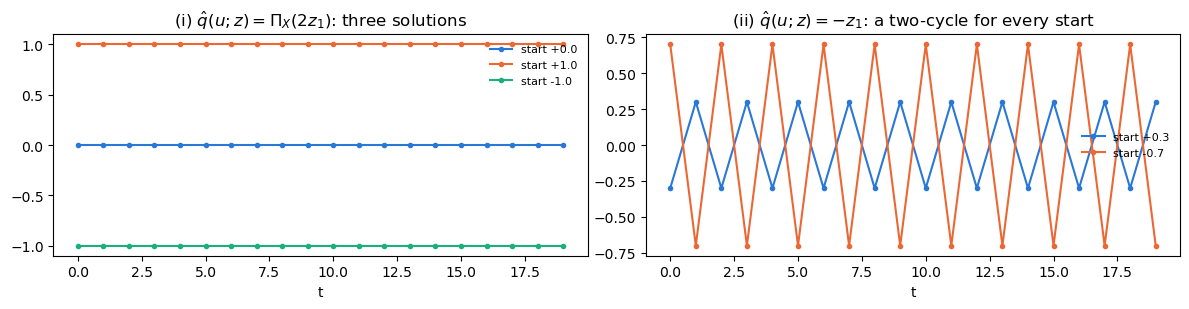

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
for z0, col in ((0.0, C_TARGET), (M, C_GEN), (-M, C_BASE)):
    ax[0].plot(run(q_doubling, z0)[:20], "o-", ms=3, color=col, label=f"start {z0:+.1f}")
ax[0].set_title(r"(i) $\hat q(u;z)=\Pi_X(2z_1)$: three solutions")
ax[0].set_xlabel("t"); ax[0].legend(fontsize=8, frameon=False)
for z0, col in ((0.3, C_TARGET), (-0.7, C_GEN)):
    ax[1].plot(run(q_flip, z0)[:20], "o-", ms=3, color=col, label=f"start {z0:+.1f}")
ax[1].set_title(r"(ii) $\hat q(u;z)=-z_1$: a two-cycle for every start")
ax[1].set_xlabel("t"); ax[1].legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

In [35]:
# The same point in a form that LOOKS like the fitted object: a one-lag map that
# is expansive but still continuous and X-valued, driven by the shared stream
# that section 9 uses, from the same 24 starts.
#
#   x_t = Pi_X(lam x_{t-1} + c(2u_t - 1)),   lam > 1,   c < (lam - 1) M.
#
# Then lam*M + c(2u-1) >= M for every u, so +M is absorbing, and likewise -M.
# For EVERY innovation stream there are therefore at least two bounded solutions
# on Z_-, and the 24 starts split permanently into two groups.  Compare with the
# trained net at factor 1 from A.1, whose spread collapses to machine zero.

class ExpansiveMap:
    def __init__(self, lam=1.6, M=1.0, c=None):
        self.lam, self.M, self.m, self.k = lam, M, 1, 1
        self.c = 0.5 * (lam - 1) * M if c is None else c
        assert self.c < (lam - 1) * M, "noise too large: the endpoints stop absorbing"

    def q(self, u, z):
        z0 = float(np.atleast_1d(z)[0])
        return float(np.clip(self.lam * z0 + self.c * (2 * float(u) - 1), -self.M, self.M))

    def q_batch(self, u, Z):
        return np.clip(self.lam * np.asarray(Z)[:, 0]
                       + self.c * (2 * np.asarray(u) - 1), -self.M, self.M)

    def generate(self, n, burn=0, seed=0, u_stream=None, z0=None):
        rng = np.random.default_rng(seed)
        u = (rng.random(burn + n) if u_stream is None
             else np.asarray(u_stream, float)[:burn + n])
        z = np.zeros(1) if z0 is None else np.asarray(z0, float).copy()
        out = np.empty(burn + n)
        for t in range(burn + n):
            out[t] = self.q(u[t], z); z[0] = out[t]
        return out[burn:]

em = ExpansiveMap(lam=1.6, M=M)
trj_e, sp_e = initial_spread(em, n_steps=120, n_starts=24, M=M)
print(f"expansive map, lam = {em.lam}:  sum_i Lip_i = {em.lam} > 1   c = {em.c:.3f}")
print("  spread at t = 0, 5, 20, 119:", np.round(sp_e[[0, 5, 20, 119]], 4).tolist())
vals, cnt = np.unique(np.round(trj_e[:, -1], 6), return_counts=True)
print("  terminal values and how many of the 24 starts reach each:",
      dict(zip(vals.tolist(), cnt.tolist())))
print(f"  trained net at factor 1 (A.1), spread at t = 119: {rows[0]['sp119']:.2e}")

expansive map, lam = 1.6:  sum_i Lip_i = 1.6 > 1   c = 0.300
  spread at t = 0, 5, 20, 119: [2.0, 2.0, 2.0, 2.0]
  terminal values and how many of the 24 starts reach each: {-1.0: 17, 1.0: 7}
  trained net at factor 1 (A.1), spread at t = 119: 2.22e-16


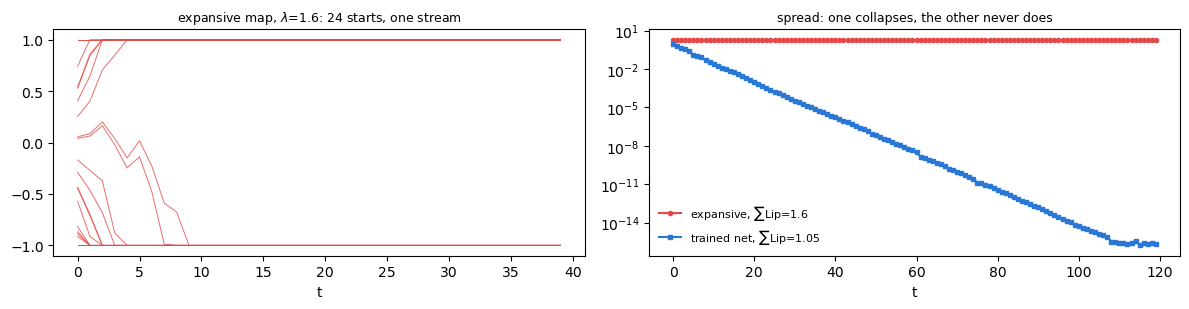

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
for tr in trj_e:
    ax[0].plot(tr[:40], lw=.7, alpha=.8, color=C_BOUND)
ax[0].set_title(fr"expansive map, $\lambda$={em.lam}: 24 starts, one stream", fontsize=9)
ax[0].set_xlabel("t")

ax[1].semilogy(np.maximum(sp_e, 1e-18), marker="o", ms=3, color=C_BOUND,
               label=fr"expansive, $\sum$Lip={em.lam}")
ax[1].semilogy(np.maximum(rows[0]["spread"], 1e-18), marker="s", ms=3, color=C_TARGET,
               label=fr"trained net, $\sum$Lip={rows[0]['lip']:.2f}")
ax[1].set_xlabel("t"); ax[1].legend(fontsize=8, frameon=False)
ax[1].set_title("spread: one collapses, the other never does", fontsize=9)
plt.tight_layout(); plt.show()

### What the two experiments say

A.1 shows the failure arriving continuously in a fitted object, and A.2 shows
it is not an artefact of fitting: two elementary continuous $\mathcal X$-valued
maps already have multiple solutions.  Together they say that contractivity in
the generator proposition is not decoration.  What it is *not* is necessary:
Appendix B shows the pathwise and adapted conclusions surviving well past
$S=1$, with the real boundary at $\lambda = 0$.

## Appendix B. A chaotic drift with stochastic forcing

Take the logistic map at $r$, carry it to $[-M,M]$, centre and rescale it so
its range covers a fraction $1-\rho$ of the interval, leaving $\rho$ for the
innovation:

$$m_0(x) = \frac{r(x+M)(M-x)}{2M} - M,\qquad \sup_{|x|\le M}|m_0'| = r,$$

$$m(x) = \gamma\,(m_0(x) - \mathrm{mid}),\quad \gamma = \frac{4(1-\rho)}{r},
\qquad X_t = m(X_{t-1}) + \rho M\,g(u_t).$$

Since $m_0$ ranges over an interval of width $Mr/2$,

$$\boxed{\;\ell_1 = \sup_{u,z}\Bigl|\frac{\partial q}{\partial z}\Bigr| = 4(1-\rho)\;}$$

**independently of $r$.**  So one knob moves the target across the standing
hypothesis, which fails for $\rho<3/4$, and keeps going, while $r$ stays pinned
in the chaotic regime.  In this package that knob is $S$ itself:
$\rho = 1 - S/4$.

The target is 1-Markov, bounded, and has a well-defined stationary law at every
$\rho$ tested.  What it does not have below $\rho=3/4$ is a uniform
contraction, so the bound $\theta/(1-S)$ is unavailable.

**The Lipschitz penalty must be off.**  At `L_max = 0.95` it would force the
learned map to be contractive, and a contractive map cannot approximate a
target with $S=3.4$.  `run_one` does this automatically; here it is explicit.
Fitting at $m=1$, the target's own order, makes the reported exponent the exact
top Lyapunov exponent rather than an upper bound.

In [37]:
S_LIST = [0.80, 2.00, 2.80, 3.40]        # rho = 0.80, 0.50, 0.30, 0.15
R_LOG, T_B, EPOCHS_B = 3.7, 40000, 120

res_b = []
for S in S_LIST:
    t = build_target("logistic", S, dict(r=R_LOG), M=M)
    p = simulate(t, T_B, burn=2000, seed=1)
    Z, X = make_windows(p, 1)
    net, _ = fit(Z, X, 1, width=256, epochs=EPOCHS_B, lip_mode="none",
                 tail_frac=0.2, M=M, seed_net=0,
                 device=DEVICE, dtype=DTYPE)
    rec = ClosedQuantileRecursion(net)

    tru = simulate(t,   T_B, burn=2000, seed=303)
    gen = simulate(rec, T_B, burn=2000, seed=404)
    us  = np.random.default_rng(7).random(22000)
    xt  = simulate(t,   20000, burn=2000, seed=0, u_stream=us)
    xh  = simulate(rec, 20000, burn=2000, seed=0, u_stream=us)
    trj_b, spread = initial_spread(rec, n_steps=120, n_starts=24, M=M)
    lam_val, exact = lyapunov(net, gen)
    lip = float(lipschitz_empirical(net, np.random.default_rng(0).uniform(-M, M, (3000, 1))).sum())
    th  = theta_hat(net, t, "data", Z_data=Z, m=1)

    nb_, sizes_, within_, centres_ = basins(trj_b)
    res_b.append(dict(S=t.S, rho=t.rho, target=t, net=net, tru=tru, gen=gen,
                      err=np.abs(xt - xh), spread=spread, trj=trj_b,
                      n_basins=nb_, sizes=sizes_, within=within_,
                      lam=lam_val, exact=exact,
                      lip=lip, theta=th, w1=w1_marginal(tru, gen),
                      sd=float(tru.std()), acf_t=acf(tru, 5)[1:], acf_g=acf(gen, 5)[1:],
                      decomp=lyapunov_decomposition(t, gen)))
    r = res_b[-1]
    print(f"rho={t.rho:.2f}  S={t.S:.2f}  lip_hat {lip:5.2f}  lambda {lam_val:+6.3f}"
          f"  theta {th:.3f}  sup|X-Xh| {r['err'].max():7.3f}"
          f"  spread40 {spread[40]:.2e}  solutions {nb_}  W1/sd {r['w1']/r['sd']:.4f}")

rho=0.80  S=0.80  lip_hat  0.74  lambda -2.179  theta 0.273  sup|X-Xh|   0.115  spread40 0.00e+00  solutions 1  W1/sd 0.0249
rho=0.50  S=2.00  lip_hat  1.74  lambda -0.628  theta 0.425  sup|X-Xh|   0.343  spread40 8.48e-11  solutions 1  W1/sd 0.0151
rho=0.30  S=2.80  lip_hat  2.39  lambda -0.109  theta 0.151  sup|X-Xh|   1.210  spread40 2.90e-02  solutions 8  W1/sd 0.0216
rho=0.15  S=3.40  lip_hat  3.05  lambda +0.201  theta 0.226  sup|X-Xh|   1.652  spread40 1.08e+00  solutions 24  W1/sd 0.0065


In [38]:
print(f"{'rho':>5}{'S':>7}{'lip_hat':>9}{'lambda':>9}{'theta':>8}"
      f"{'theta/(1-S)':>13}{'sup|X-Xh|':>11}{'spread40':>11}{'W1/sd':>8}{'ACF1 t/g':>18}")
for r in res_b:
    b = f"{r['theta']/(1-r['S']):.3f}" if r["S"] < 1 else "void"
    print(f"{r['rho']:5.2f}{r['S']:7.2f}{r['lip']:9.2f}{r['lam']:+9.3f}{r['theta']:8.3f}"
          f"{b:>13}{r['err'].max():11.3f}{r['spread'][40]:11.2e}"
          f"{r['w1']/r['sd']:8.4f}   {r['acf_t'][0]:+.3f} / {r['acf_g'][0]:+.3f}")

print("\nthe TARGET's exponent, decomposed along the generated path:")
print("  lambda = log 4(1-rho) + E log|X|/M .  The second term is strictly negative")
print("  because |X| <= M, which is exactly why S = 4(1-rho) can exceed 1 while")
print("  lambda stays negative.  The autograd column is the LEARNED map's exponent;")
print("  the two agree once the fit has converged, and a gap means it has not.")
for r in res_b:
    d = r["decomp"]
    print(f"  rho={r['rho']:.2f}   {d['log_sup_slope']:+.4f} {d['E_log_abs_X_over_M']:+.4f}"
          f"  = {d['lambda_analytic']:+.4f} (target)   vs {r['lam']:+.4f} (learned)"
          f"   geometric mean |X| = {d['geometric_mean_abs_X']:.3f}")

  rho      S  lip_hat   lambda   theta  theta/(1-S)  sup|X-Xh|   spread40   W1/sd          ACF1 t/g
 0.80   0.80     0.74   -2.179   0.273        1.363      0.115   0.00e+00  0.0249   -0.111 / -0.113
 0.50   2.00     1.74   -0.628   0.425         void      0.343   8.48e-11  0.0151   -0.516 / -0.520
 0.30   2.80     2.39   -0.109   0.151         void      1.210   2.90e-02  0.0216   -0.715 / -0.712
 0.15   3.40     3.05   +0.201   0.226         void      1.652   1.08e+00  0.0065   -0.725 / -0.722

the TARGET's exponent, decomposed along the generated path:
  lambda = log 4(1-rho) + E log|X|/M .  The second term is strictly negative
  because |X| <= M, which is exactly why S = 4(1-rho) can exceed 1 while
  lambda stays negative.  The autograd column is the LEARNED map's exponent;
  the two agree once the fit has converged, and a gap means it has not.
  rho=0.80   -0.2231 -1.5421  = -1.7652 (target)   vs -2.1792 (learned)   geometric mean |X| = 0.214
  rho=0.50   +0.6931 -1.3232  = -0.6301

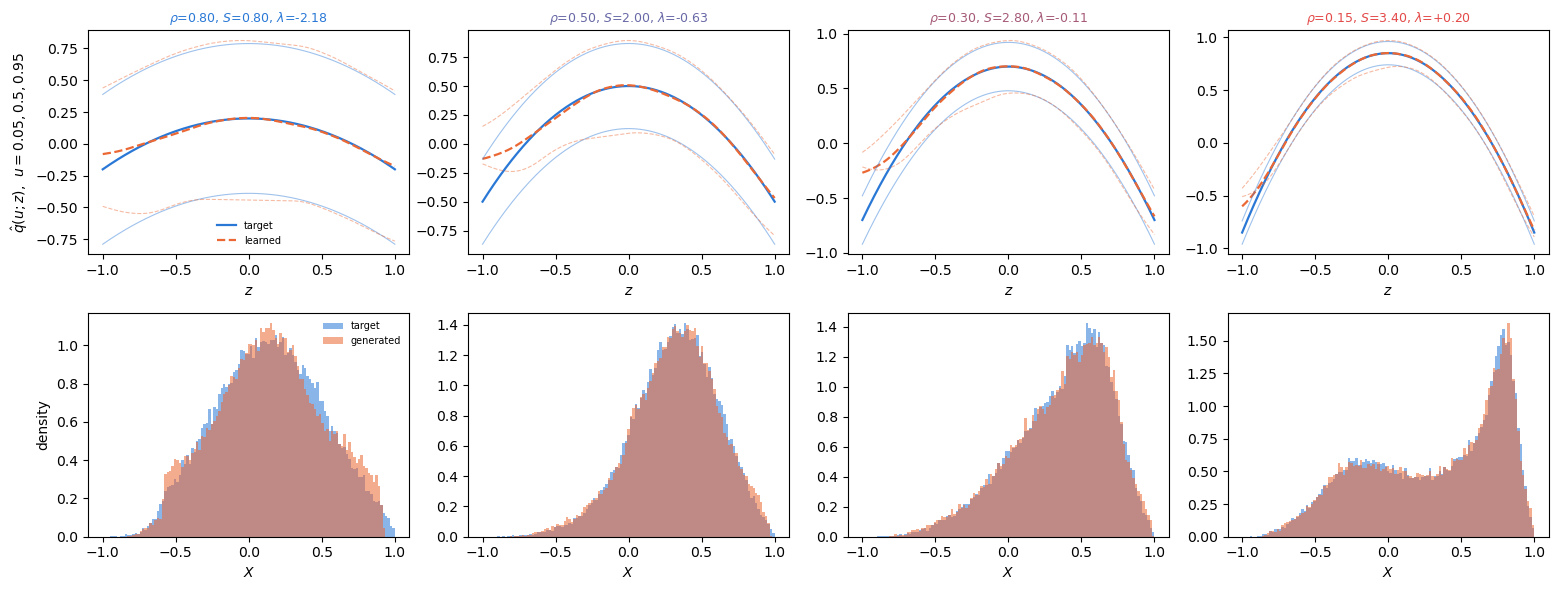

In [39]:
# B, figure 1: the MAP and the MARGINAL at every rho, which is the demanding
# test.  The invariant density of a noisy logistic map is spiky and asymmetric,
# so an overlay either lands on it or obviously does not; and the top row shows
# WHERE the fit is wrong in z, which no aggregate over z can.
cols = ramp(len(res_b))
fig, ax = plt.subplots(2, len(res_b), figsize=(3.9 * len(res_b), 6))
zg = np.linspace(-M, M, 400)[:, None]
for j, r in enumerate(res_b):
    for uu, lw_, al in ((0.5, 1.6, 1.0), (0.05, .8, .45), (0.95, .8, .45)):
        uv = np.full(len(zg), uu)
        ax[0, j].plot(zg[:, 0], r["target"].q(uv, zg), color=C_TARGET, lw=lw_, alpha=al,
                      label="target" if uu == 0.5 else None)
        ax[0, j].plot(zg[:, 0], r["net"].q_np(uv, zg), color=C_GEN, ls="--", lw=lw_,
                      alpha=al, label="learned" if uu == 0.5 else None)
    ax[0, j].set_title(fr"$\rho$={r['rho']:.2f}, $S$={r['S']:.2f}, "
                       fr"$\lambda$={r['lam']:+.2f}", fontsize=9, color=cols[j])
    ax[0, j].set_xlabel("$z$")
    if j == 0:
        ax[0, j].set_ylabel(r"$\hat q(u;z)$,  $u=0.05, 0.5, 0.95$")
        ax[0, j].legend(fontsize=7, frameon=False)
    bb = np.linspace(-M, M, 120)
    ax[1, j].hist(r["tru"], bins=bb, density=True, alpha=.55, color=C_TARGET, label="target")
    ax[1, j].hist(r["gen"], bins=bb, density=True, alpha=.55, color=C_GEN, label="generated")
    ax[1, j].set_xlabel("$X$")
    if j == 0:
        ax[1, j].set_ylabel("density"); ax[1, j].legend(fontsize=7, frameon=False)
plt.tight_layout(); plt.show()

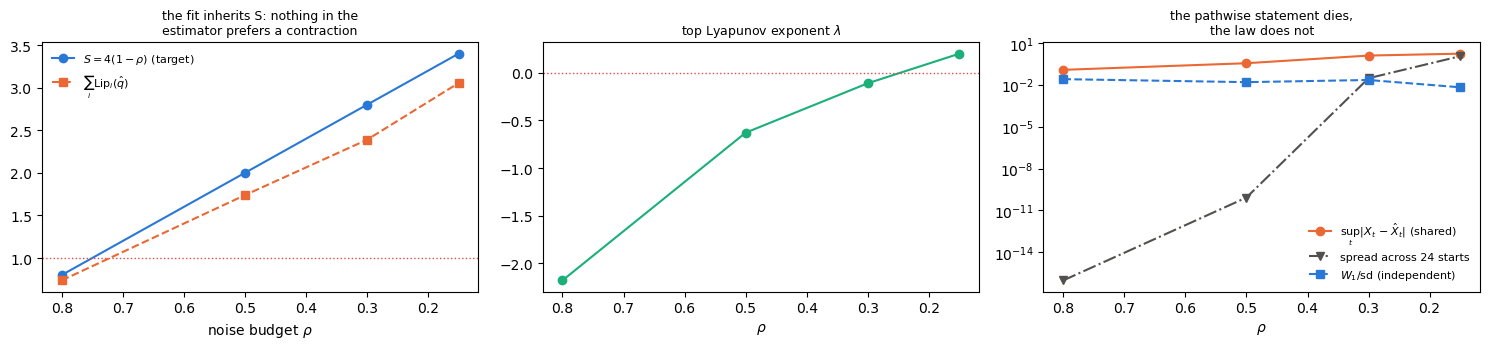

In [40]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
rh = np.array([r["rho"] for r in res_b])

ax[0].plot(rh, [r["S"] for r in res_b], "o-", color=C_TARGET, label=r"$S = 4(1-\rho)$ (target)")
ax[0].plot(rh, [r["lip"] for r in res_b], "s--", color=C_GEN, label=r"$\sum_i$Lip$_i(\hat q)$")
ax[0].axhline(1, color=C_BOUND, ls=":", lw=1)
ax[0].set_xlabel(r"noise budget $\rho$"); ax[0].invert_xaxis()
ax[0].legend(fontsize=8, frameon=False)
ax[0].set_title("the fit inherits S: nothing in the\nestimator prefers a contraction", fontsize=9)

ax[1].plot(rh, [r["lam"] for r in res_b], "o-", color=C_BASE)
ax[1].axhline(0, color=C_BOUND, ls=":", lw=1)
ax[1].set_xlabel(r"$\rho$"); ax[1].invert_xaxis()
ax[1].set_title(r"top Lyapunov exponent $\lambda$", fontsize=9)

ax[2].semilogy(rh, [max(r["err"].max(), 1e-14) for r in res_b], "o-", color=C_GEN,
               label=r"$\sup_t|X_t-\hat X_t|$ (shared)")
ax[2].semilogy(rh, [max(r["spread"][40], 1e-16) for r in res_b], "v-.", color=C_RULE,
               label="spread across 24 starts")
ax[2].semilogy(rh, [r["w1"] / r["sd"] for r in res_b], "s--", color=C_TARGET,
               label=r"$W_1$/sd (independent)")
ax[2].set_xlabel(r"$\rho$"); ax[2].invert_xaxis(); ax[2].legend(fontsize=8, frameon=False)
ax[2].set_title("the pathwise statement dies,\nthe law does not", fontsize=9)
plt.tight_layout(); plt.show()

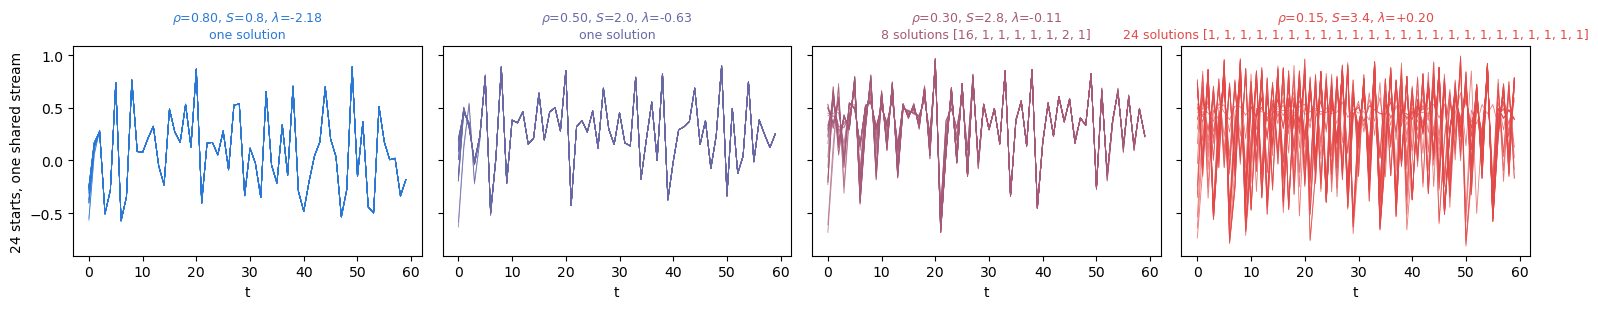

terminal spread across the 24 starts, and how many distinct solutions:
  rho=0.80  S=0.80  lambda -2.179   spread(t=119) 0.00e+00   solutions 1 [24]   worst within-solution spread 0.0e+00
  rho=0.50  S=2.00  lambda -0.628   spread(t=119) 0.00e+00   solutions 1 [24]   worst within-solution spread 0.0e+00
  rho=0.30  S=2.80  lambda -0.109   spread(t=119) 4.35e-05   solutions 8 [16, 1, 1, 1, 1, 1, 2, 1]   worst within-solution spread 1.9e-06
  rho=0.15  S=3.40  lambda +0.201   spread(t=119) 1.28e+00   solutions 24 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]   worst within-solution spread 0.0e+00


In [41]:
# B: the paths behind the spread, one panel per rho.  The spread curve says a
# number collapsed or did not; these panels say WHAT the 24 chains did -- merge
# into one solution, or separate and stay separated.  That is the difference
# between "the recursion has a unique solution" and "it has several", and it is
# the thing a scalar cannot show.
cols = ramp(len(res_b))
fig, ax = plt.subplots(1, len(res_b), figsize=(3.9 * len(res_b), 3.2), sharey=True)
for j, (r, c) in enumerate(zip(res_b, cols)):
    for tr in r["trj"]:
        ax[j].plot(tr[:60], lw=.6, alpha=.75, color=c)
    ok = "one solution" if r["n_basins"] == 1 else f"{r['n_basins']} solutions {r['sizes']}"
    ax[j].set_title(fr"$\rho$={r['rho']:.2f}, $S$={r['S']:.1f}, $\lambda$={r['lam']:+.2f}"
                    "\n" + ok, fontsize=9, color=c)
    ax[j].set_xlabel("t")
ax[0].set_ylabel("24 starts, one shared stream")
plt.tight_layout(); plt.show()

print("terminal spread across the 24 starts, and how many distinct solutions:")
for r in res_b:
    print(f"  rho={r['rho']:.2f}  S={r['S']:.2f}  lambda {r['lam']:+.3f}"
          f"   spread(t=119) {r['spread'][-1]:.2e}"
          f"   solutions {r['n_basins']} {r['sizes']}"
          f"   worst within-solution spread {r['within']:.1e}")

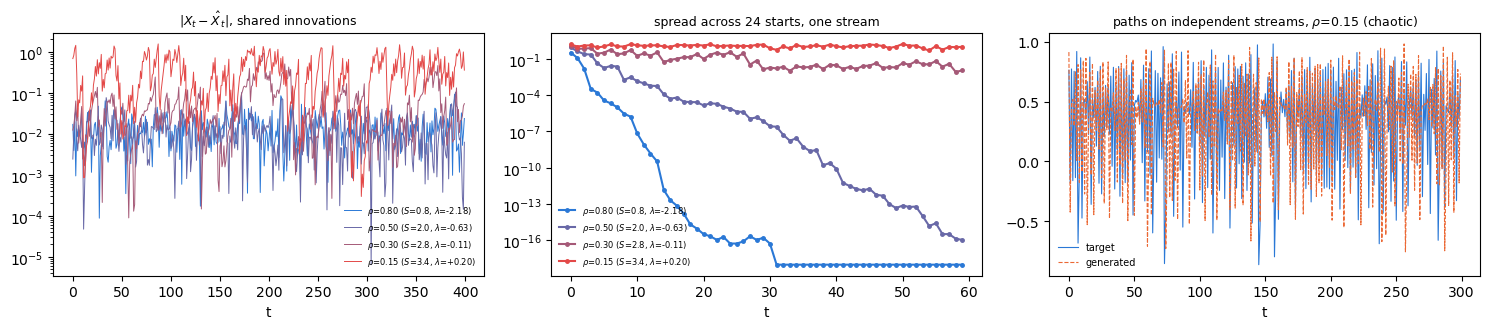

In [42]:
# B, figure 3: synchronisation as a function of t, per rho.  The regime diagram
# above reduces each of these curves to one number; the curves show that the
# pathwise error does not grow gradually with S but changes character once
# lambda crosses zero, and that the spread does the same.
cols = ramp(len(res_b))
fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
for r, c in zip(res_b, cols):
    lab = fr"$\rho$={r['rho']:.2f} ($S$={r['S']:.1f}, $\lambda$={r['lam']:+.2f})"
    ax[0].semilogy(np.maximum(r["err"][:400], 1e-14), lw=.7, color=c, label=lab)
    ax[1].semilogy(np.maximum(r["spread"][:60], 1e-18), marker="o", ms=2.5,
                   color=c, label=lab)
ax[0].set_xlabel("t"); ax[0].legend(fontsize=6, frameon=False)
ax[0].set_title(r"$|X_t-\hat X_t|$, shared innovations", fontsize=9)
ax[1].set_xlabel("t"); ax[1].legend(fontsize=6, frameon=False)
ax[1].set_title("spread across 24 starts, one stream", fontsize=9)

rc = res_b[-1]
ax[2].plot(rc["tru"][:300], lw=.8, color=C_TARGET, label="target")
ax[2].plot(rc["gen"][:300], lw=.8, ls="--", color=C_GEN, label="generated")
ax[2].set_xlabel("t"); ax[2].legend(fontsize=7, frameon=False)
ax[2].set_title(fr"paths on independent streams, $\rho$={rc['rho']:.2f} (chaotic)",
                fontsize=9)
plt.tight_layout(); plt.show()

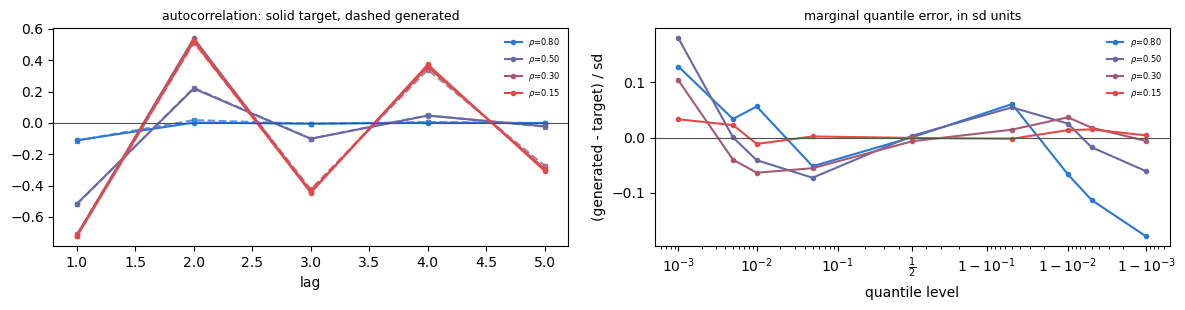

In [43]:
# B, figure 4: the law, across the whole sweep rather than at its endpoint.
# Solid target, dashed generated, one colour per rho.
cols = ramp(len(res_b))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
for r, c in zip(res_b, cols):
    ax[0].plot(np.r_[1:6], r["acf_t"], "o-", color=c, ms=3,
               label=fr"$\rho$={r['rho']:.2f}")
    ax[0].plot(np.r_[1:6], r["acf_g"], "s--", color=c, ms=3, alpha=.75)
ax[0].axhline(0, color=C_RULE, lw=.8); ax[0].set_xlabel("lag")
ax[0].set_title("autocorrelation: solid target, dashed generated", fontsize=9)
ax[0].legend(fontsize=6, frameon=False)

qs = np.array([0.001, 0.005, 0.01, 0.05, 0.5, 0.95, 0.99, 0.995, 0.999])
for r, c in zip(res_b, cols):
    qt = np.quantile(r["tru"], qs)
    ax[1].plot(qs, (np.quantile(r["gen"], qs) - qt) / r["sd"], "o-", ms=3, color=c,
               label=fr"$\rho$={r['rho']:.2f}")
ax[1].axhline(0, color=C_RULE, lw=.8); ax[1].set_xscale("logit")
ax[1].set_xlabel("quantile level"); ax[1].set_ylabel("(generated - target) / sd")
ax[1].set_title("marginal quantile error, in sd units", fontsize=9)
ax[1].legend(fontsize=6, frameon=False)
plt.tight_layout(); plt.show()

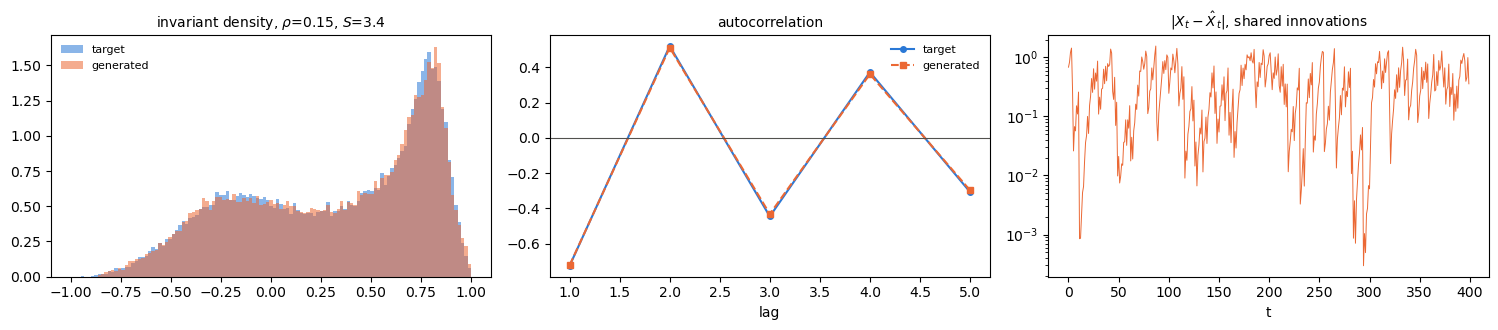

In [44]:
# the chaotic end, in detail: a spiky invariant density recovered exactly while
# the pathwise coupling has completely failed
r = res_b[-1]
fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
bb = np.linspace(-M, M, 120)
ax[0].hist(r["tru"], bins=bb, density=True, alpha=.55, color=C_TARGET, label="target")
ax[0].hist(r["gen"], bins=bb, density=True, alpha=.55, color=C_GEN, label="generated")
ax[0].set_title(fr"invariant density, $\rho$={r['rho']:.2f}, $S$={r['S']:.1f}", fontsize=10)
ax[0].legend(fontsize=8, frameon=False)

ax[1].plot(np.r_[1:6], r["acf_t"], "o-", color=C_TARGET, ms=4, label="target")
ax[1].plot(np.r_[1:6], r["acf_g"], "s--", color=C_GEN, ms=4, label="generated")
ax[1].axhline(0, color=C_RULE, lw=.8); ax[1].set_xlabel("lag")
ax[1].set_title("autocorrelation", fontsize=10); ax[1].legend(fontsize=8, frameon=False)

ax[2].semilogy(np.maximum(r["err"][:400], 1e-12), lw=.7, color=C_GEN)
ax[2].set_xlabel("t"); ax[2].set_title(r"$|X_t-\hat X_t|$, shared innovations", fontsize=10)
plt.tight_layout(); plt.show()

### The three regimes

**This is the figure to cite for "the hypothesis is sufficient and not
necessary".**  Measured at this appendix's own budget ($T=40{,}000$, 120 epochs,
`lip_mode="none"`, one seed), the four points are:

| $\rho$ | $S$ | $\sum_i\mathrm{Lip}_i(\hat q)$ | $\lambda$ | spread $t{=}40$ | spread $t{=}119$ | distinct solutions | $\sup_t\lvert X-\hat X\rvert$ | $W_1$/sd |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 0.80 | 0.80 | 0.74 | $-2.179$ | 0 | 0 | **1** | 0.115 | 0.0249 |
| 0.50 | 2.00 | 1.74 | $-0.629$ | 8.2e−11 | 0 | **1** | 0.342 | 0.0151 |
| 0.30 | 2.80 | 2.39 | $-0.109$ | 2.9e−02 | 5.0e−05 | **8** | 1.210 | 0.0216 |
| 0.15 | 3.40 | 3.05 | $+0.198$ | 1.05 | 1.30 | **24** | 1.664 | 0.0074 |

The `distinct solutions` column is the one to read, and it is sharper than the
spread. Uniqueness holds **outright through $S=2.00$** — one solution, spread
exactly zero, with $\sum_i\mathrm{Lip}_i=1.74$ already well past the hypothesis.
At $S=2.80$ it is **marginal rather than holding**: $\lambda=-0.109$ is still
negative and the spread has fallen to $5\times10^{-5}$, but the 24 starts sit in
8 distinguishable clusters. At $S=3.40$, where $\lambda=+0.198>0$, it fails
completely: 24 separate solutions and a spread at the full diameter $2M$.

So the number of solutions goes $1 \to 1 \to 8 \to 24$ as $\lambda$ crosses
zero, and the analytic crossing is at $\rho\approx0.28$, i.e. $S\approx2.88$,
which is exactly between the last two points and why $S=2.80$ is the marginal
one.

| | hypothesis | conclusion |
|---|---|---|
| $S<1$ | holds | $\theta/(1-S)$ valid, and slack by roughly an order of magnitude |
| $S\ge1$, $\lambda<0$ | fails | pathwise closeness survives anyway; synchronisation still occurs |
| $\lambda>0$ | fails | the pathwise statement is void; the **law** is still recovered |

So on this family $\sum_i\ell_i<1$ is sufficient and short of necessary by
roughly a factor of **two to three**: uniqueness survives intact to $S=2.0$ and
is marginal at $S=2.8$.  The operative boundary for the pathwise and adapted
statements is $\lambda<0$, which is the criterion the stochastic echo state
property literature uses.

**One caution carried over from Appendix A.**  That $\lambda$ is the operative
boundary *here* is a property of this family, not a general fact. In A the same
$\lambda$ stays negative while uniqueness fails, because rescaling $G$ splits the
state space into two basins and $\lambda$ — an average along one trajectory —
cannot see a second one. The two appendices agree about $\lambda$ only because
B's forcing is additive and large enough to keep the state space a single
ergodic class. The honest general statement is that $\lambda<0$ is **necessary
and not sufficient**, and that a synchronisation claim needs the basin count
alongside it.

Two further readings.

**Nothing in the estimator prefers a contraction.**  With the penalty off, the
fitted $\sum_i\mathrm{Lip}_i$ tracks the target's $S$ to within a few per cent
at every point, $S=3.4$ included.  Whatever contraction the main experiment's
fits exhibit came from the penalty and from the target, not from the method.

**The failure is entirely in the amplification.**  $\theta$ is essentially flat
across the sweep: the approximation does not degrade as the target becomes
chaotic.  It is $1/(1-S)$ that breaks, which is the cleanest statement of what
the contraction hypothesis is doing in the theorem.  It is not there to make
the target learnable; it is there to stop the error compounding.

**Reading it against the main notebook.**  Section 10 there exhibits a
generator that passes the path-law diagnostics while getting the conditional
law wrong.  This appendix is the other half: a generator that gets the law
right, marginals, tails and autocorrelation, while the adapted statement is
void.  The pair is why the adapted distance is the certificate and the path
law is not.